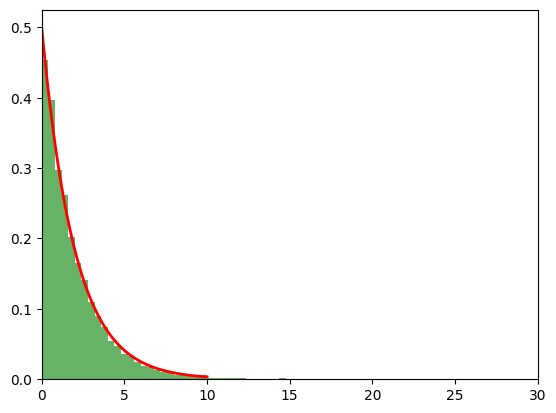

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats import skew, norm
from scipy.stats import skew, kurtosis, norm
from scipy.stats import skew, kurtosis, norm, chi2



# generate data 
N = 10000
n = 1000
x = np.random.normal(0, 1, (N,n))
G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=True)
G2 = kurtosis(x, axis=1, fisher=True, bias=True) * np.sqrt(n / 24)   
G3 = G1**2+G2**2

plt.hist(G3, bins=100, density=True, alpha=0.6, color='g')
x = np.linspace(0, 10, 100)
plt.xlim(0,30)
plt.plot(x, chi2.pdf(x, df=2), 'r-', lw=2, label='chi2 pdf')    
plt.show()

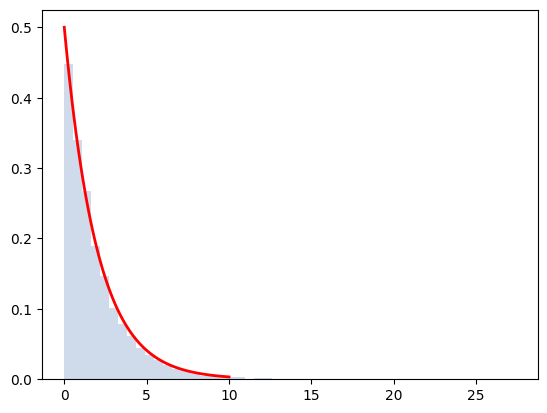

In [24]:
#define a function to compute G3 statstic, return the ststistic and the p-value 
def G3_stat(x):
    n = x.shape[1]
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=True)
    G2 = kurtosis(x, axis=1, fisher=True, bias=True) * np.sqrt(n / 24)   
    G3 = G1**2+G2**2
    p = 1 - chi2.cdf(G3, df=2)  
    return G3, p

N = 10000
n = 1000
x = np.random.normal(0, 1, (N,n))
G3, p = G3_stat(x)  
plt.hist(G3, bins=50, density=True, alpha=0.6, color= '#B0C4DE')
x = np.linspace(0, 10, 100)
plt.plot(x, chi2.pdf(x, df=2), 'r-', lw=2, label='chi2 pdf')    
plt.show()  

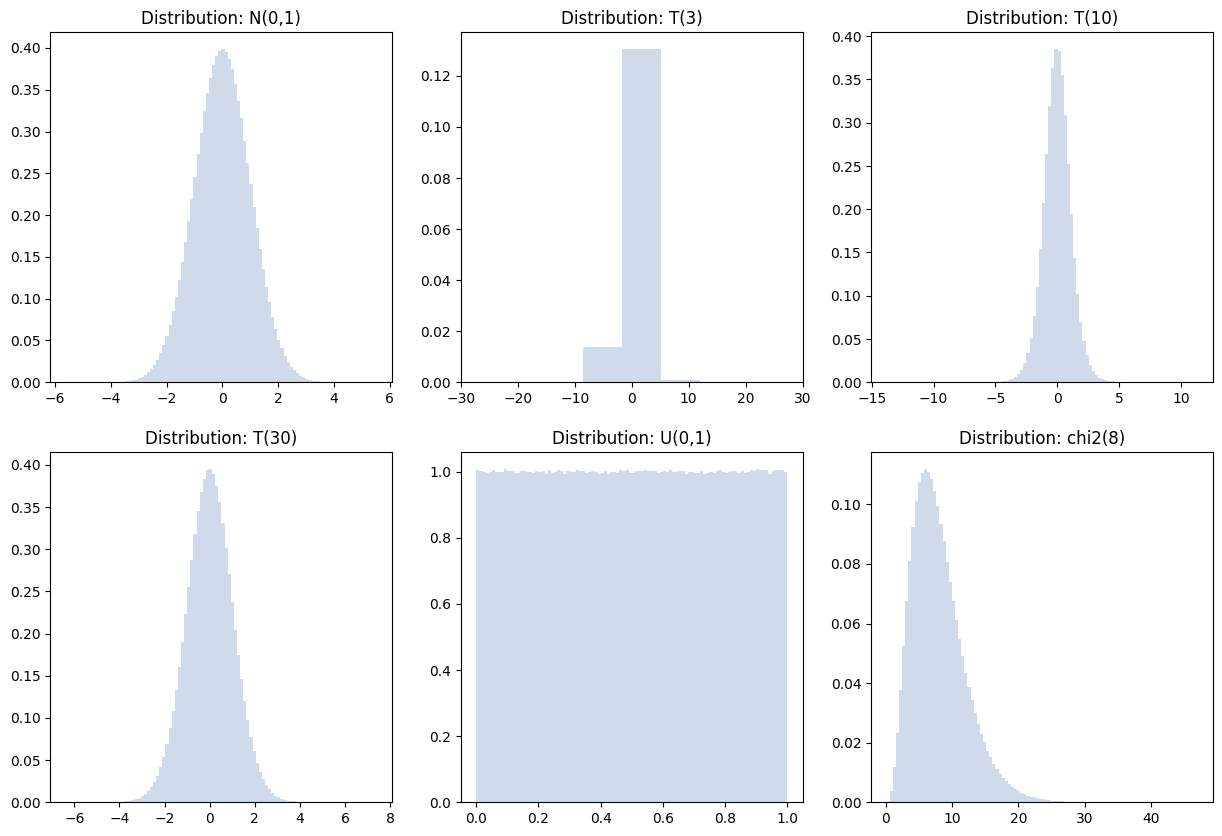

p-value: 6.472600233564662e-18


In [43]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.stats import t, uniform, chi2, norm, kurtosis, skew  



def G3_stat(x):
    #write multiple comments using triple quotes    
    """
    Input: 
        x is a 2D numpy array of shape (N, n) where N is the number of samples and n is the number of observations in each sample    
    Output:
        G3: numpy array of shape (N,) containing the G3 statistic for each sample
        p: numpy array of shape (N,) containing the p-value for each sample
    """
    n = x.shape[1]
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=False)
    G2 = kurtosis(x, axis=1, fisher=True, bias=True) * np.sqrt(n / 24)   
    G3 = G1**2+G2**2
    p = 1 - chi2.cdf(G3, df=2)  
    return G3, p

distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

#Function to generate data from a specified distribution    
def generate_data(distribution_name, size):
    if distribution_name in distributions:  
        return distributions[distribution_name](size)   
    else:
        raise ValueError('Unknown distribution')

size = 1000 
distribution_names = ['N(0,1)', 'T(3)', 'T(10)', 'T(30)', 'U(0,1)', 'chi2(8)']  

# Generate and plot data from each distribution  
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()
for i, name in enumerate(distribution_names):
    data = generate_data(name, (N, size)).flatten()  # Ensure correct shape
    axs[i].hist(data, bins=100, density=True, alpha=0.6, color='#B0C4DE')
    x = np.linspace(0, 10, 1000)   
    axs[i].set_title(f'Distribution: {name}')
    if name == 'T(3)':
        axs[i].set_xlim(-30, 30)  # Set x-axis range for T(3)
plt.show()  
print('p-value:', p.mean())






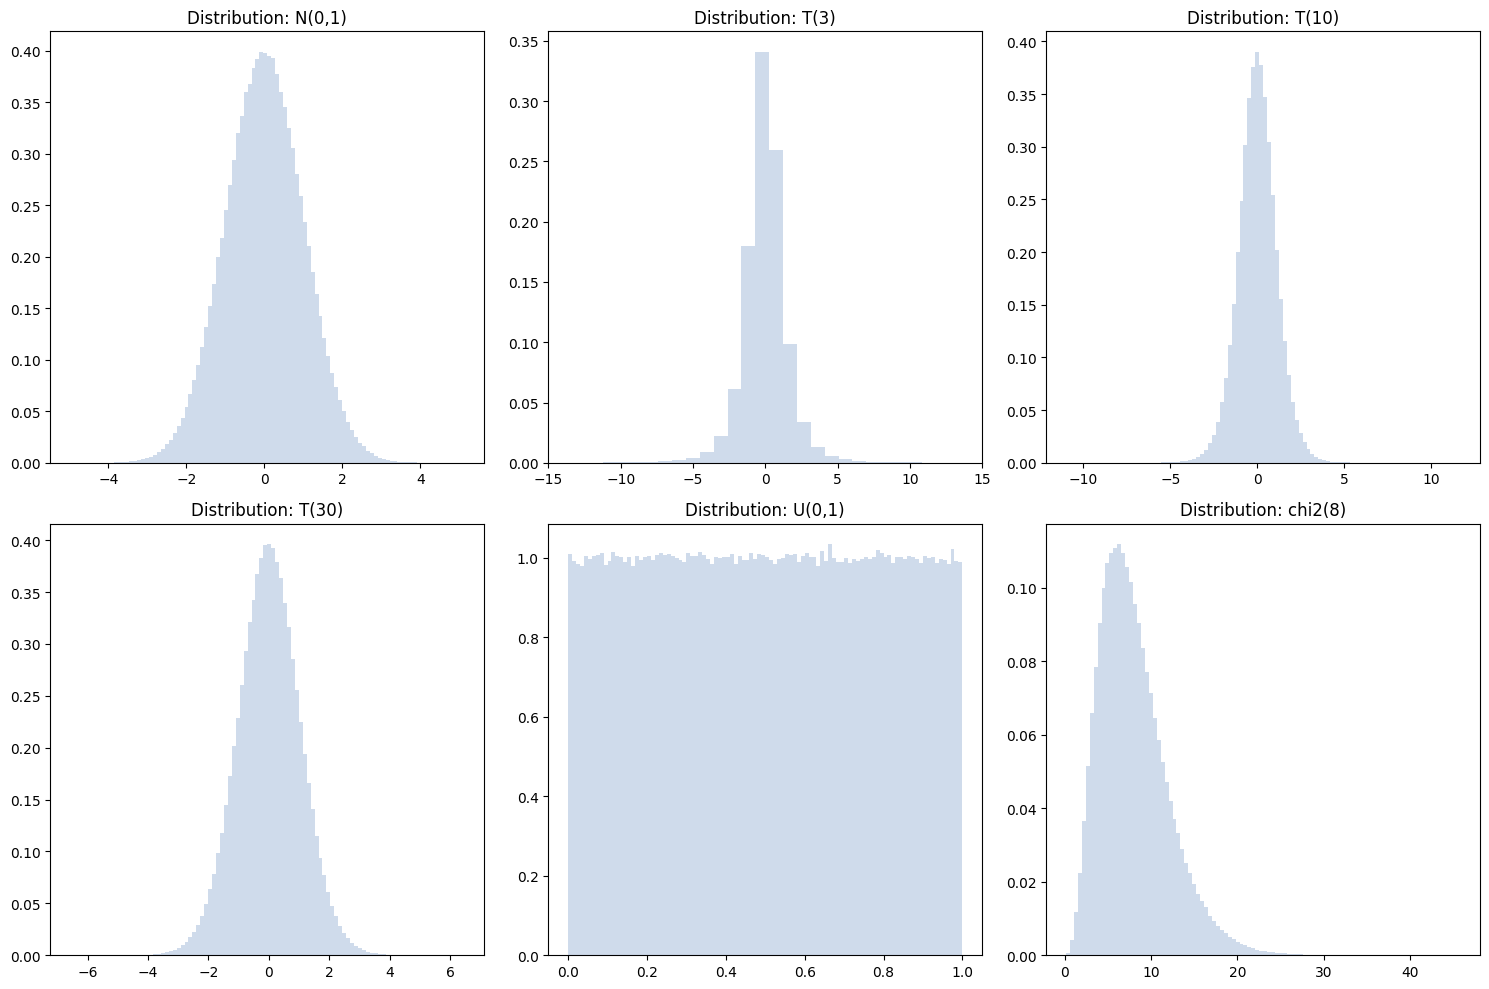

In [48]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.stats import t, uniform, chi2, norm, kurtosis, skew  

def G3_stat(x):
    """
    Input: 
        x is a 2D numpy array of shape (N, n) where N is the number of samples and n is the number of observations in each sample    
    Output:
        G3: numpy array of shape (N,) containing the G3 statistic for each sample
        p: numpy array of shape (N,) containing the p-value for each sample
    """
    n = x.shape[1]
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=False)
    G2 = kurtosis(x, axis=1, fisher=True, bias=True) * np.sqrt(n / 24)   
    G3 = G1**2 + G2**2
    p = 1 - chi2.cdf(G3, df=2)  
    return G3, p

distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

def generate_data(distribution_name, size):
    if distribution_name in distributions:  
        return distributions[distribution_name](size)   
    else:
        raise ValueError('Unknown distribution')

size = 1000 
distribution_names = ['N(0,1)', 'T(3)', 'T(10)', 'T(30)', 'U(0,1)', 'chi2(8)']  

# Generate and plot data from each distribution  
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()
for i, name in enumerate(distribution_names):
    data = generate_data(name, (size, size)).flatten()  # Ensure correct shape
    bins = 300 if name == 'T(3)' else 100  # Set bins to 200 for T(3), otherwise 100
    axs[i].hist(data, bins=bins, density=True, alpha=0.6, color='#B0C4DE')
    axs[i].set_title(f'Distribution: {name}')
    if name == 'T(3)':
        axs[i].set_xlim(-15, 15)  # Set x-axis range for T(3)
plt.tight_layout()
plt.show()

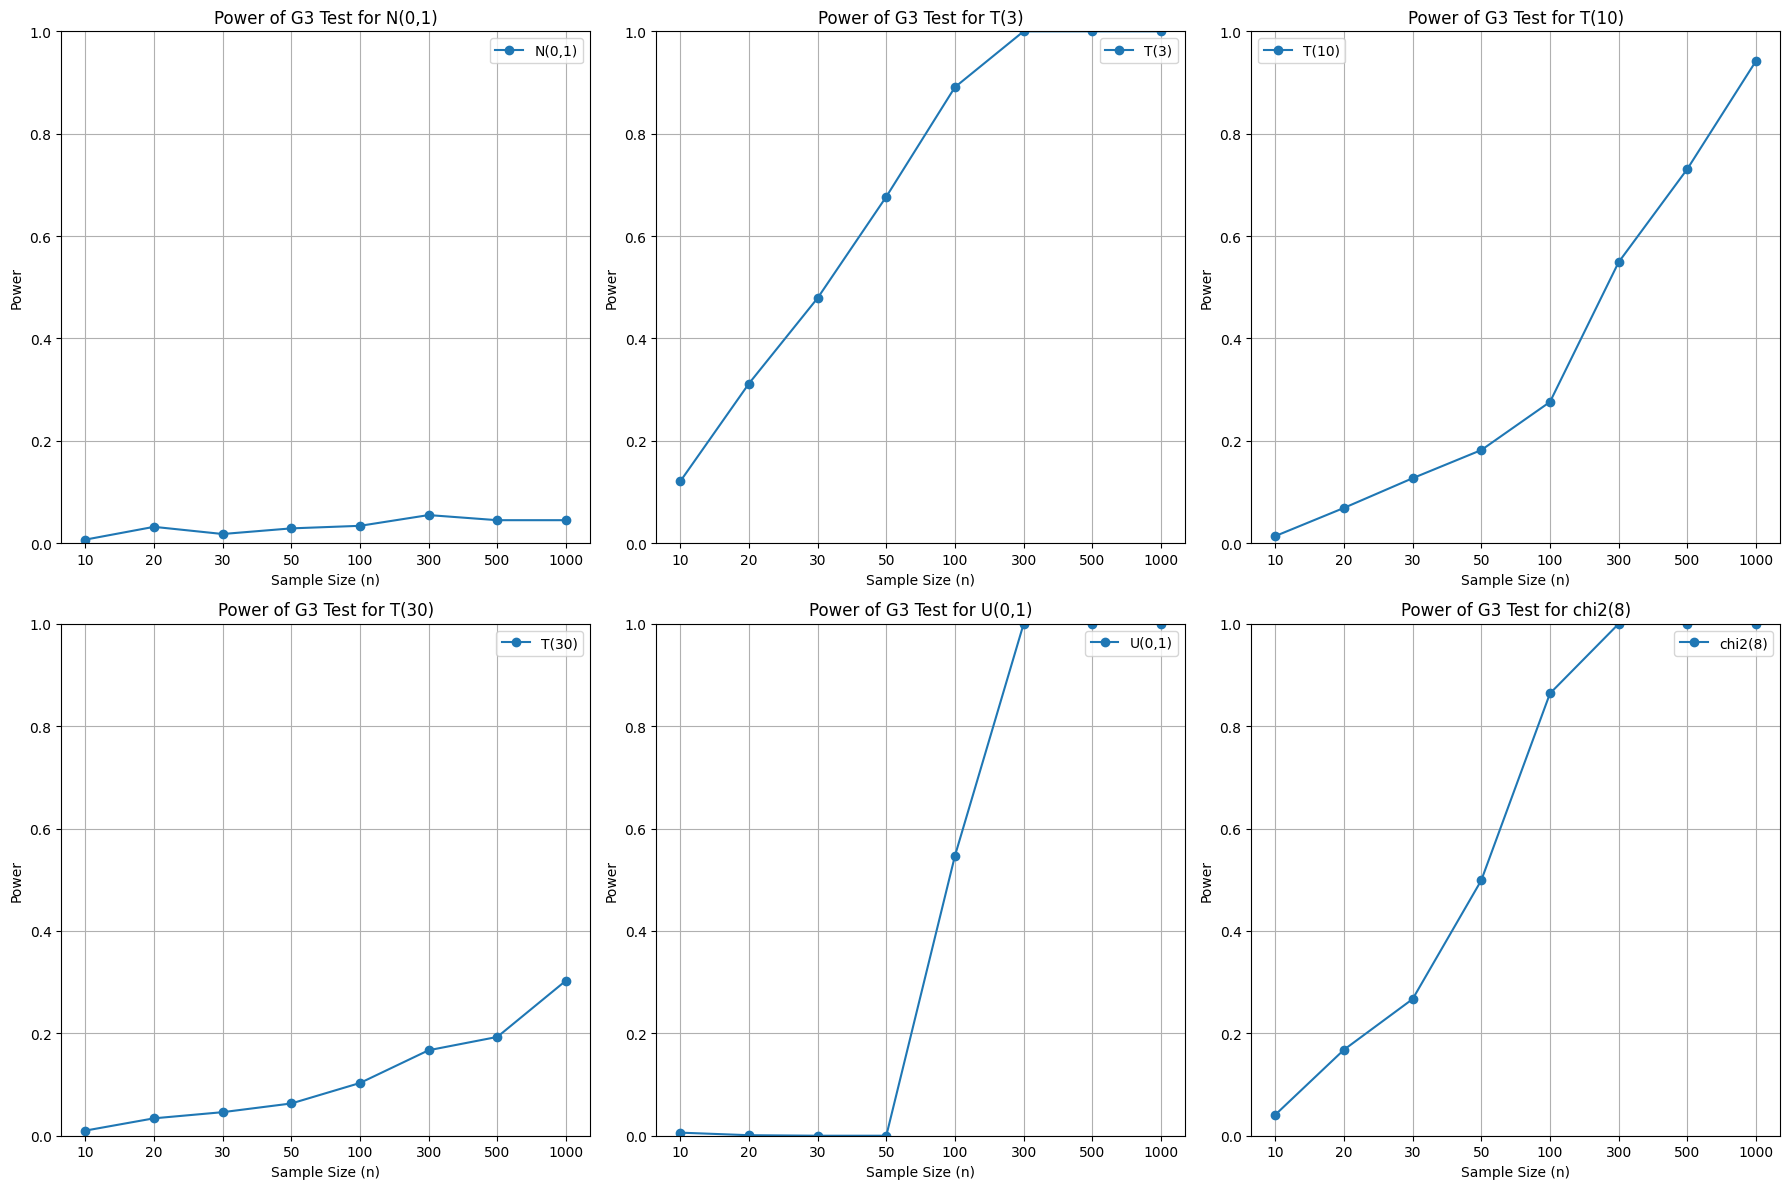

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, t, uniform, chi2, norm
 


# 定義分佈母體
N = 1000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05 
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}


def G3_stat(x):
     n = x.shape[1]
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=False)
    G2 = kurtosis(x, axis=1, fisher=True, bias=True) * np.sqrt(n / 24)   
    G3 = G1**2 + G2**2
    return G3, 1 - chi2.cdf(G3, df=2)  


# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        power_G3 = 0
        
        for _ in range(N):
            x = dist_func(n)
            s = skew(x)
            k = kurtosis(x, fisher=True)
            G1 = np.sqrt(n / 6) * s
            G2 = np.sqrt(n / 24) * (k)
            G3 = G1**2 + G2**2
            
            # 檢驗 G3 統計量
            p_value = 1 - chi2.cdf(G3, df=2)
            if p_value < alpha:
                power_G3 += 1
        
        power_values[dist_name].append(power_G3 / N)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    ax.set_ylim(0, 1)  # 設置 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, t, uniform, chi2, norm

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, t, uniform, chi2, norm

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 50000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {dist: [] for dist in distributions}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        power_G3 = 0
        
        for _ in range(N):
            x = dist_func(n)
            s = skew(x)
            k = kurtosis(x, fisher=True)
            G1 = np.sqrt(n / 6) * s
            G2 = np.sqrt(n / 24) * (k)
            G3 = G1**2 + G2**2
            
            # 檢驗 G3 統計量
            p_value = 1 - chi2.cdf(G3, df=2)
            if p_value < alpha:
                power_G3 += 1
        
        power_values[dist_name].append(power_G3 / N)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# 設定實驗參數
N = 100  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {dist: [] for dist in distributions}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        power_G3 = 0
        
        for _ in range(N):
            x = dist_func(n)
            s = skew(x)
            k = kurtosis(x, fisher=True)
            G1 = np.sqrt(n / 6) * s
            G2 = np.sqrt(n / 24) * (k)
            G3 = G1**2 + G2**2
            
            # 檢驗 G3 統計量
            p_value = 1 - chi2.cdf(G3, df=2)
            if p_value < alpha:
                power_G3 += 1
        
        power_values[dist_name].append(power_G3 / N)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3176675680.py, line 13)

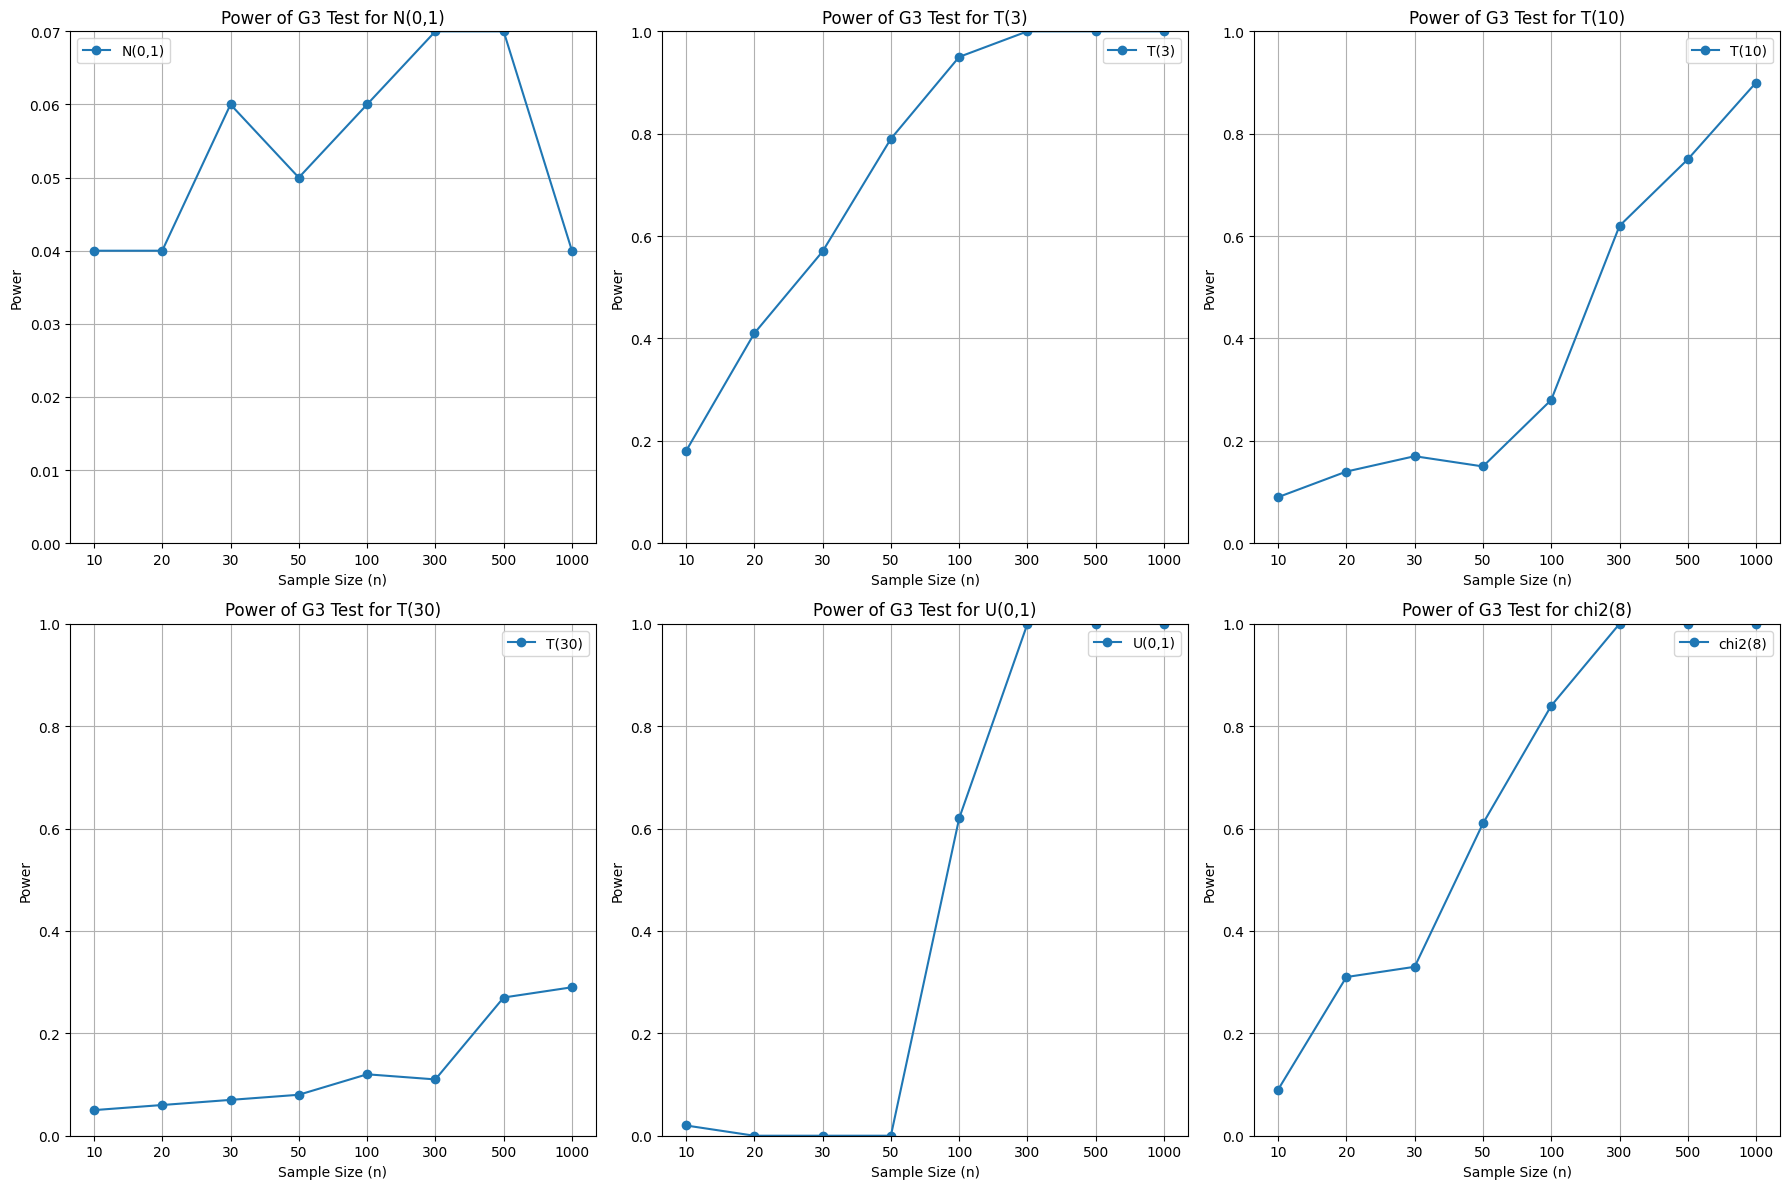

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, t, uniform, chi2, norm

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 100  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {dist: [] for dist in distributions}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        power_G3 = 0 
        
        for _ in range(N):
            x = dist_func(n)
            s = skew(x)
            k = kurtosis(x, fisher=True, bias=False)
            G1 = np.sqrt(n / 6) * s
            G2 = np.sqrt(n / 24) * (k)
            G3 = G1**2 + G2**2
            
            # 檢驗 G3 統計量
            p_value = 1 - chi2.cdf(G3, df=2)
            if p_value < alpha:
                power_G3 += 1
        
        power_values[dist_name].append(power_G3 / N)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, t, uniform, chi2, norm

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 100  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {dist: [] for dist in distributions} #建立一個字典，用來存放每個分佈的 power 值 


# 進行實驗
for dist_name, dist_func in distributions.items(): #從 distributions 字典中取出每個分佈的名稱和函數
    for n in n_values:
        power_G3 = 0 
        
        for _ in range(N):
            x = dist_func(n)
            s = skew(x)
            k = kurtosis(x, fisher=True)
            G1 = np.sqrt(n / 6) * s
            G2 = np.sqrt(n / 24) * (k)
            G3 = G1**2 + G2**2
           
            # 檢驗 G3 統計量
            p_value = 1 - chi2.cdf(G3, df=2)
            if p_value < alpha:
                power_G3 += 1
        
        power_values[dist_name].append(power_G3 / N)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

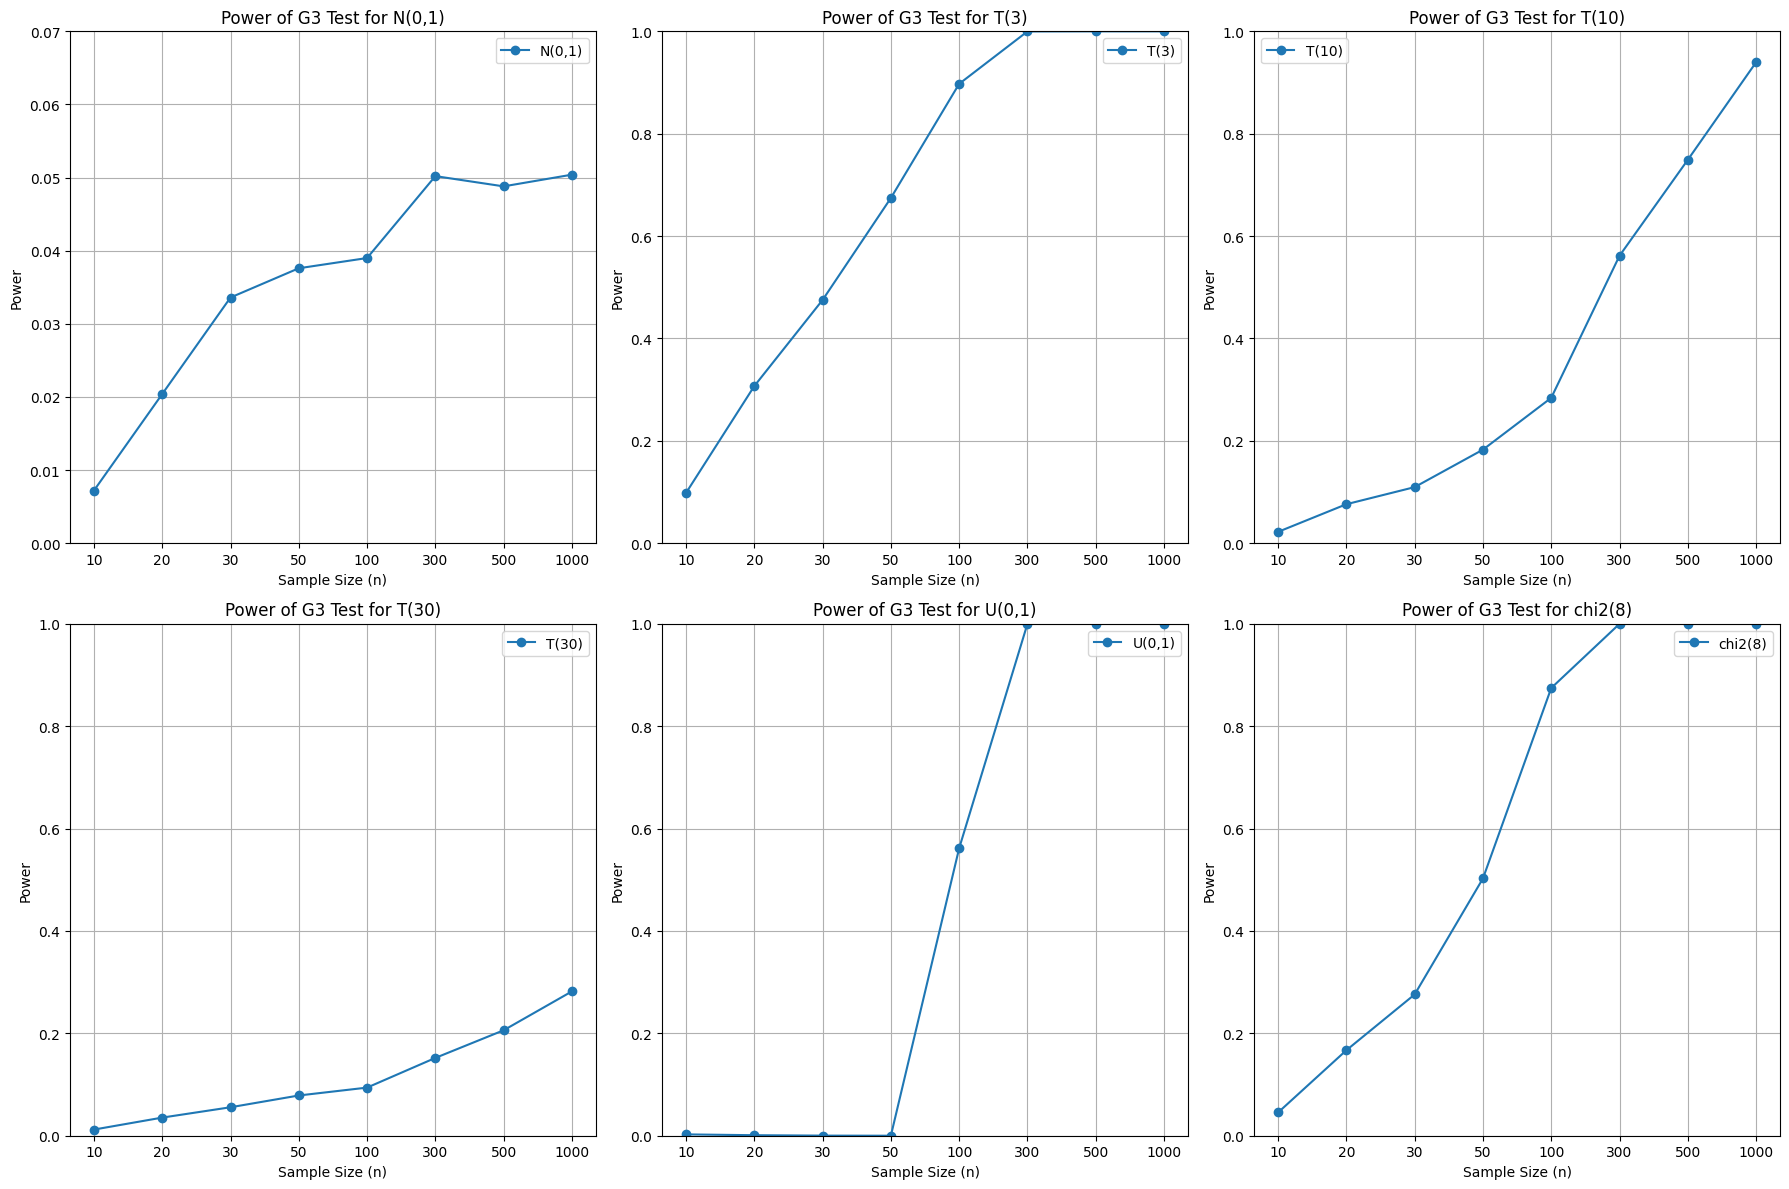

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, t, uniform, chi2, norm

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 5000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {dist: [] for dist in distributions}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        power_G3 = 0 
        
        for _ in range(N):
            x = dist_func(n)
            s = skew(x)
            k = kurtosis(x, fisher=True)
            G1 = np.sqrt(n / 6) * s
            G2 = np.sqrt(n / 24) * (k)
            G3 = G1**2 + G2**2
            
            # 檢驗 G3 統計量
            p_value = 1 - chi2.cdf(G3, df=2)
            if p_value < alpha:
                power_G3 += 1
        
        power_values[dist_name].append(power_G3 / N)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

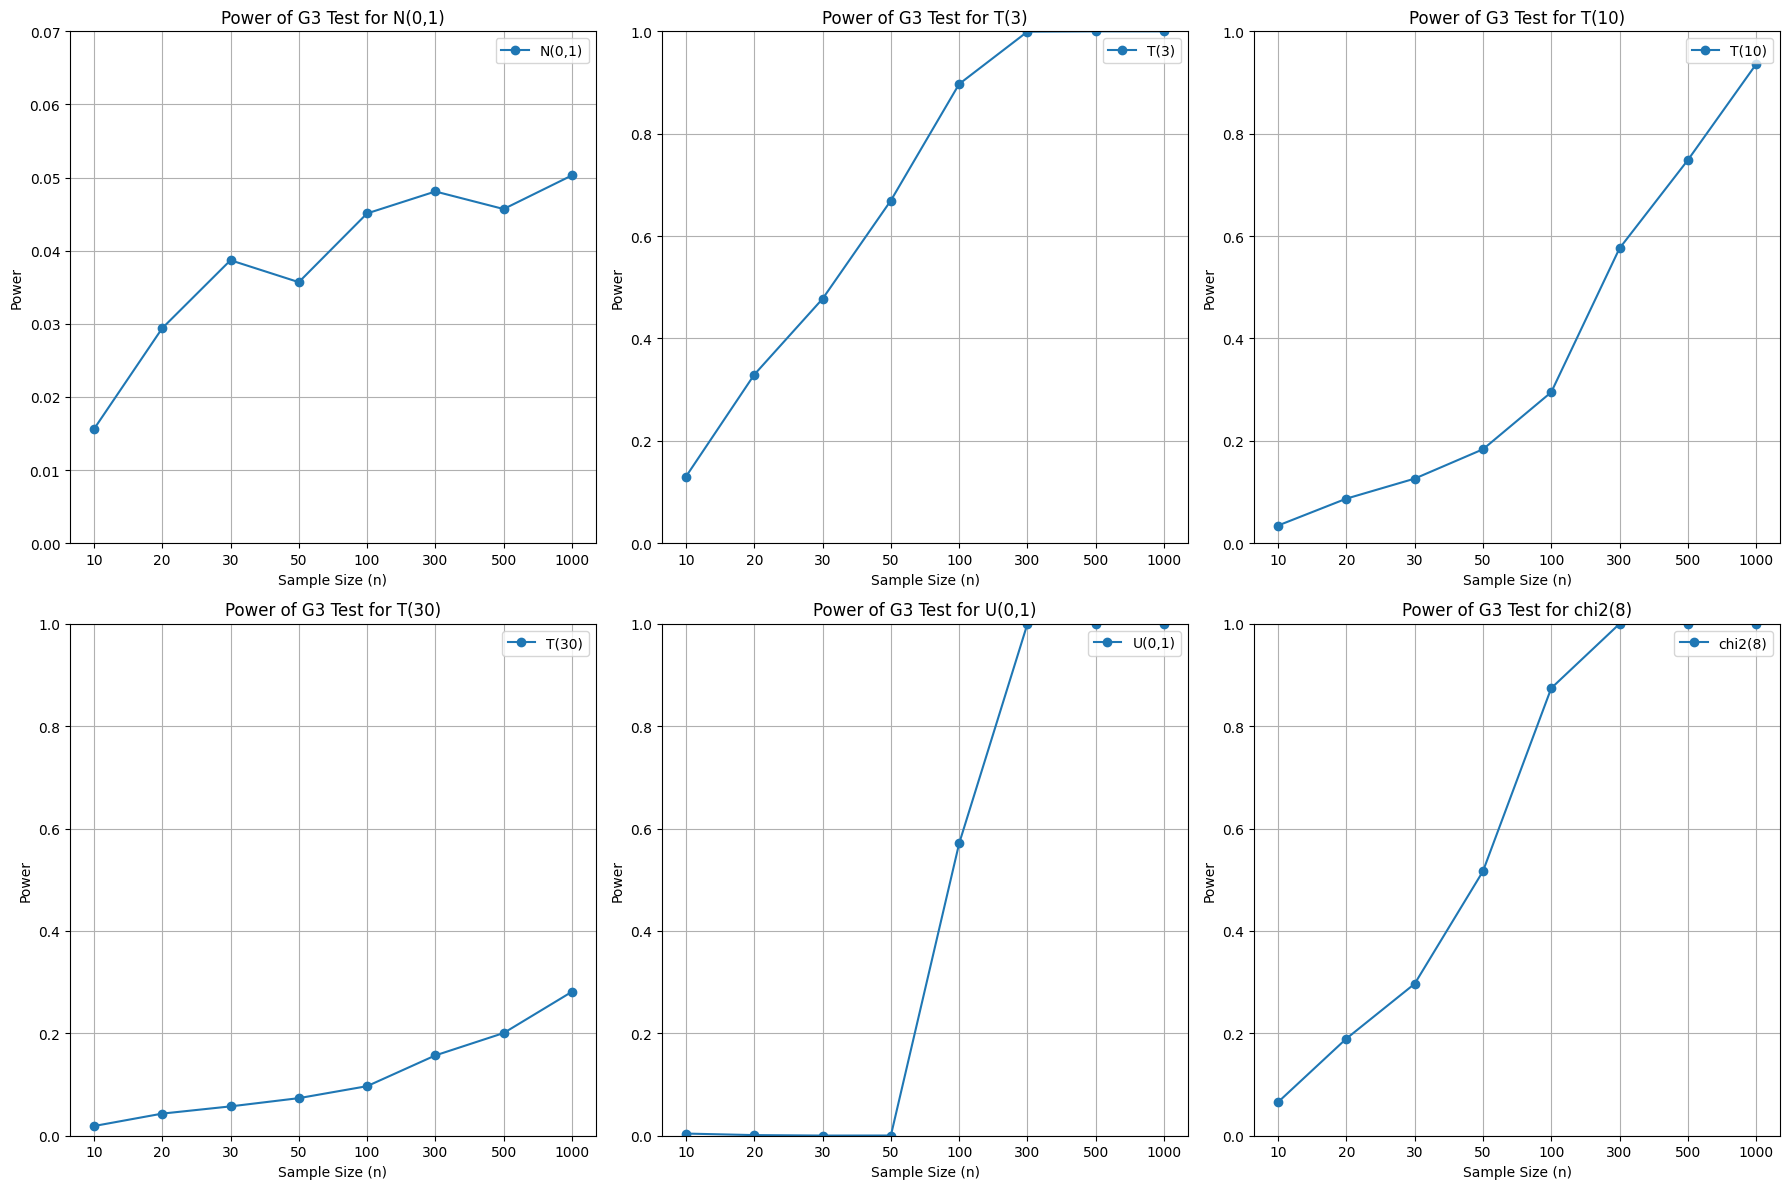

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, t, uniform, chi2, norm

def JB_test(x):
    """
    檢驗資料是否來自常態分佈的 Jarque-Bera 檢定。
    
    參數:
    x : array_like
        欲檢定是否為常態的一組資料。
    
    返回:
    stats : float
        G_3 檢定統計量的值。
    p_value : float
        檢定的 p-value。
    """
    n = len(x)
    G1 = np.sqrt(n / 6) * skew(x, bias=False)
    G2 = np.sqrt(n / 24) * (kurtosis(x, fisher=True, bias=False) - 3)
    G3 = G1**2 + G2**2
    p_value = 1 - chi2.cdf(G3, df=2)
    return G3, p_value

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 10000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {dist: [] for dist in distributions}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        x = dist_func((N, n))  # 生成 N 個樣本，每個樣本大小為 n
        G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=False)
        G2 = np.sqrt(n / 24) * (kurtosis(x, axis=1, fisher=True))
        G3 = G1**2 + G2**2
        p_values = 1 - chi2.cdf(G3, df=2)
        power = np.mean(p_values < alpha)  # 計算檢定力
        power_values[dist_name].append(power)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

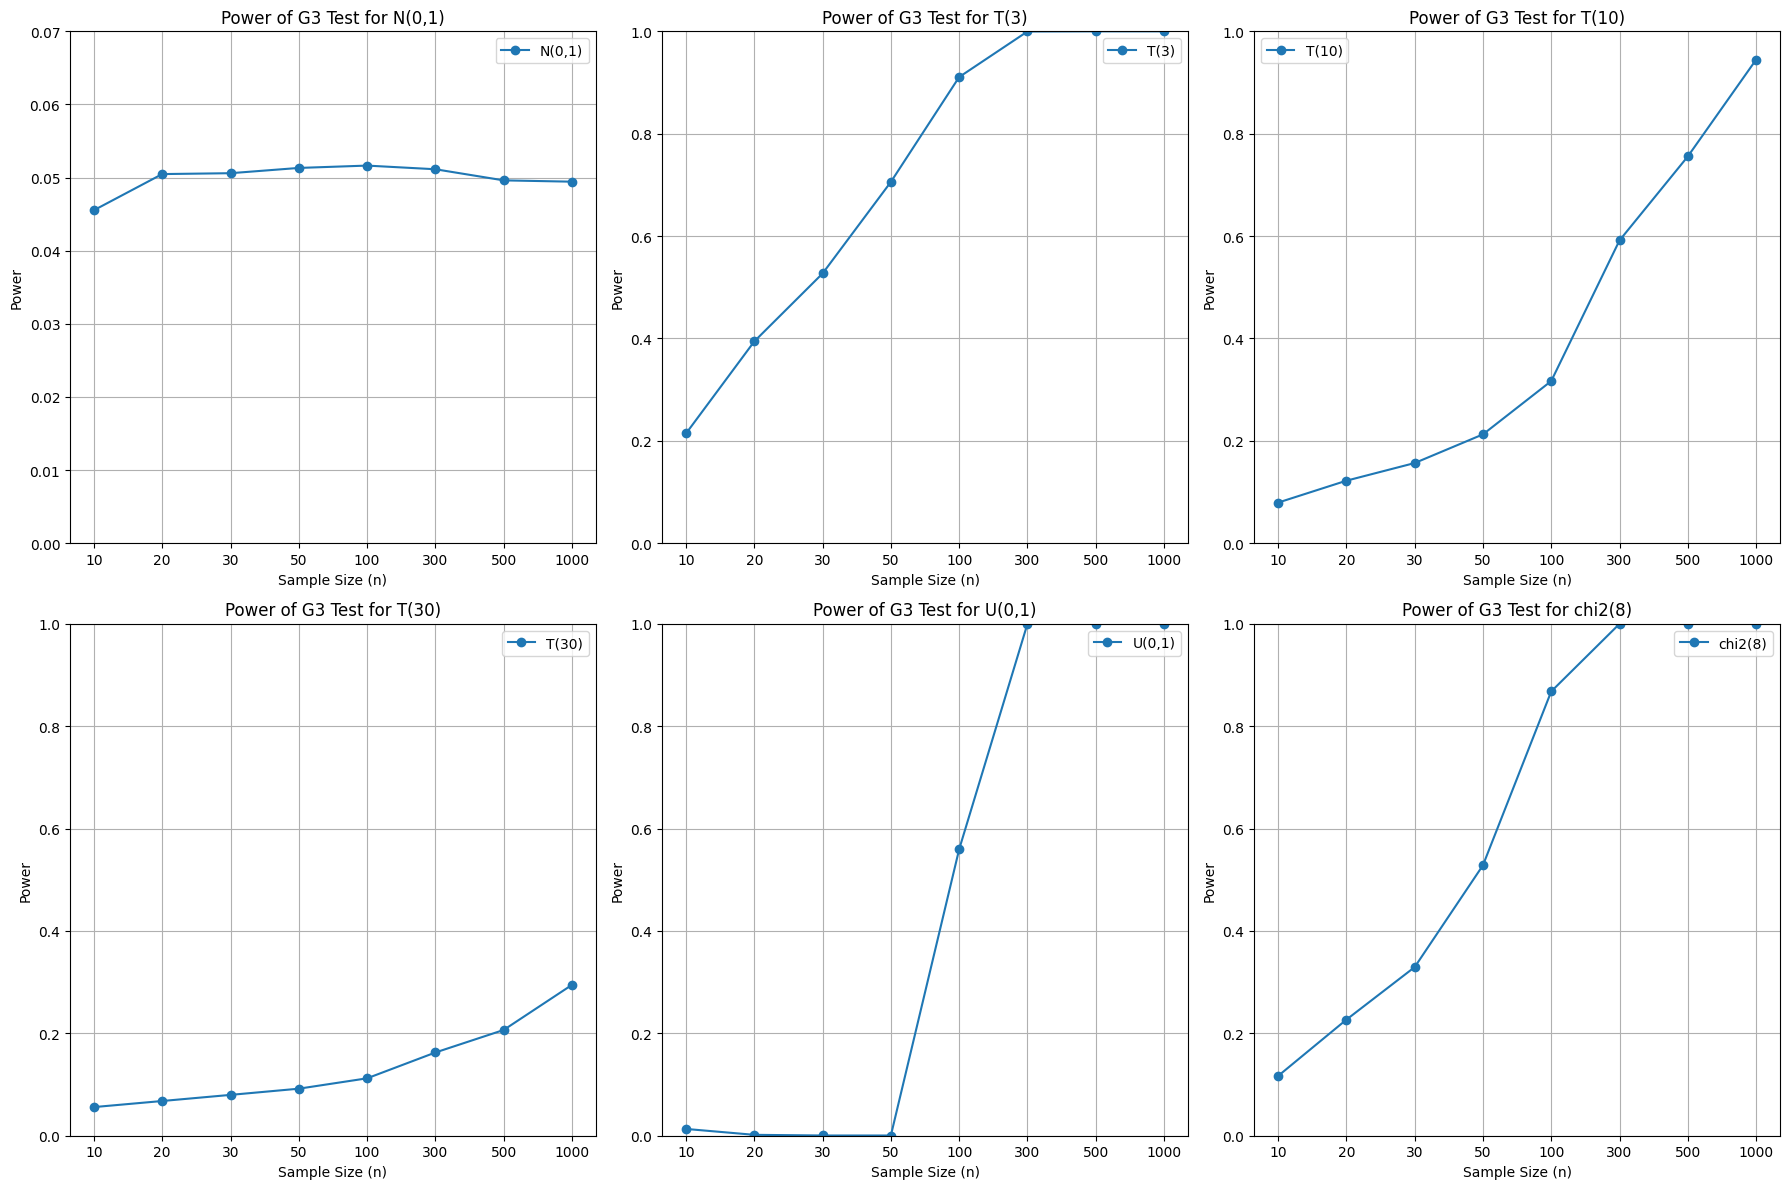

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, chi2, t, uniform

def JB_test(x):
    """
    檢驗資料是否來自常態分佈的 Jarque-Bera 檢定。
    
    參數:
    x : array_like
        欲檢定是否為常態的一組資料。
    
    返回:
    stats : float
        G_3 檢定統計量的值。
    p_value : float
        檢定的 p-value。
    """
    n = x.shape[1]
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=False)
    G2 = np.sqrt(n / 24) * (kurtosis(x, axis=1, bias = False, fisher=True ) )
    G3 = G1**2 + G2**2
    p_value = 1 - chi2.cdf(G3, df=2)
    return G3, p_value

# 定義分佈母體
distributions = {
    'N(0,1)': lambda size: np.random.normal(0, 1, size),
    'T(3)': lambda size: t.rvs(df=3, size=size),
    'T(10)': lambda size: t.rvs(df=10, size=size),
    'T(30)': lambda size: t.rvs(df=30, size=size),
    'U(0,1)': lambda size: uniform.rvs(0, 1, size=size),
    'chi2(8)': lambda size: chi2.rvs(df=8, size=size)
}

# 設定實驗參數
N = 50000  # 重複實驗次數
n_values = [10, 20, 30, 50, 100, 300, 500, 1000]  # 樣本大小
alpha = 0.05  # 顯著性水平
power_values = {dist: [] for dist in distributions}

# 進行實驗
for dist_name, dist_func in distributions.items():
    for n in n_values:
        x = dist_func((N, n))  # 生成 N 個樣本，每個樣本大小為 n
        G3, p_values = JB_test(x)
        power = np.mean(p_values < alpha)  # 計算檢定力
        power_values[dist_name].append(power)

# 繪製六張小圖
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
x_positions = np.arange(len(n_values))  # x 軸平均分配的位置

for i, (dist_name, power_vals) in enumerate(power_values.items()):
    ax = axs[i // 3, i % 3]
    ax.plot(x_positions, power_vals, marker='o', label=dist_name)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(n_values)
    ax.set_xlabel('Sample Size (n)')
    ax.set_ylabel('Power')
    if i == 0:
        ax.set_ylim(0, 0.07)  # 設置第一張圖的 y 軸範圍
    else:
        ax.set_ylim(0, 1)  # 設置其他圖的 y 軸範圍
    ax.set_title(f'Power of G3 Test for {dist_name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()